## Task 1: Exploratory Data Analysis (EDA):

1.	Load the dataset and perform basic data exploration.

2.	Examine the distribution of features using histograms, box plots, or density plots.

3.	Investigate correlations between features to understand relationships within the data.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Now import sklearn and run KMeans
from sklearn.cluster import KMeans

df = pd.read_csv('wine.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df['Type'].value_counts())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           No

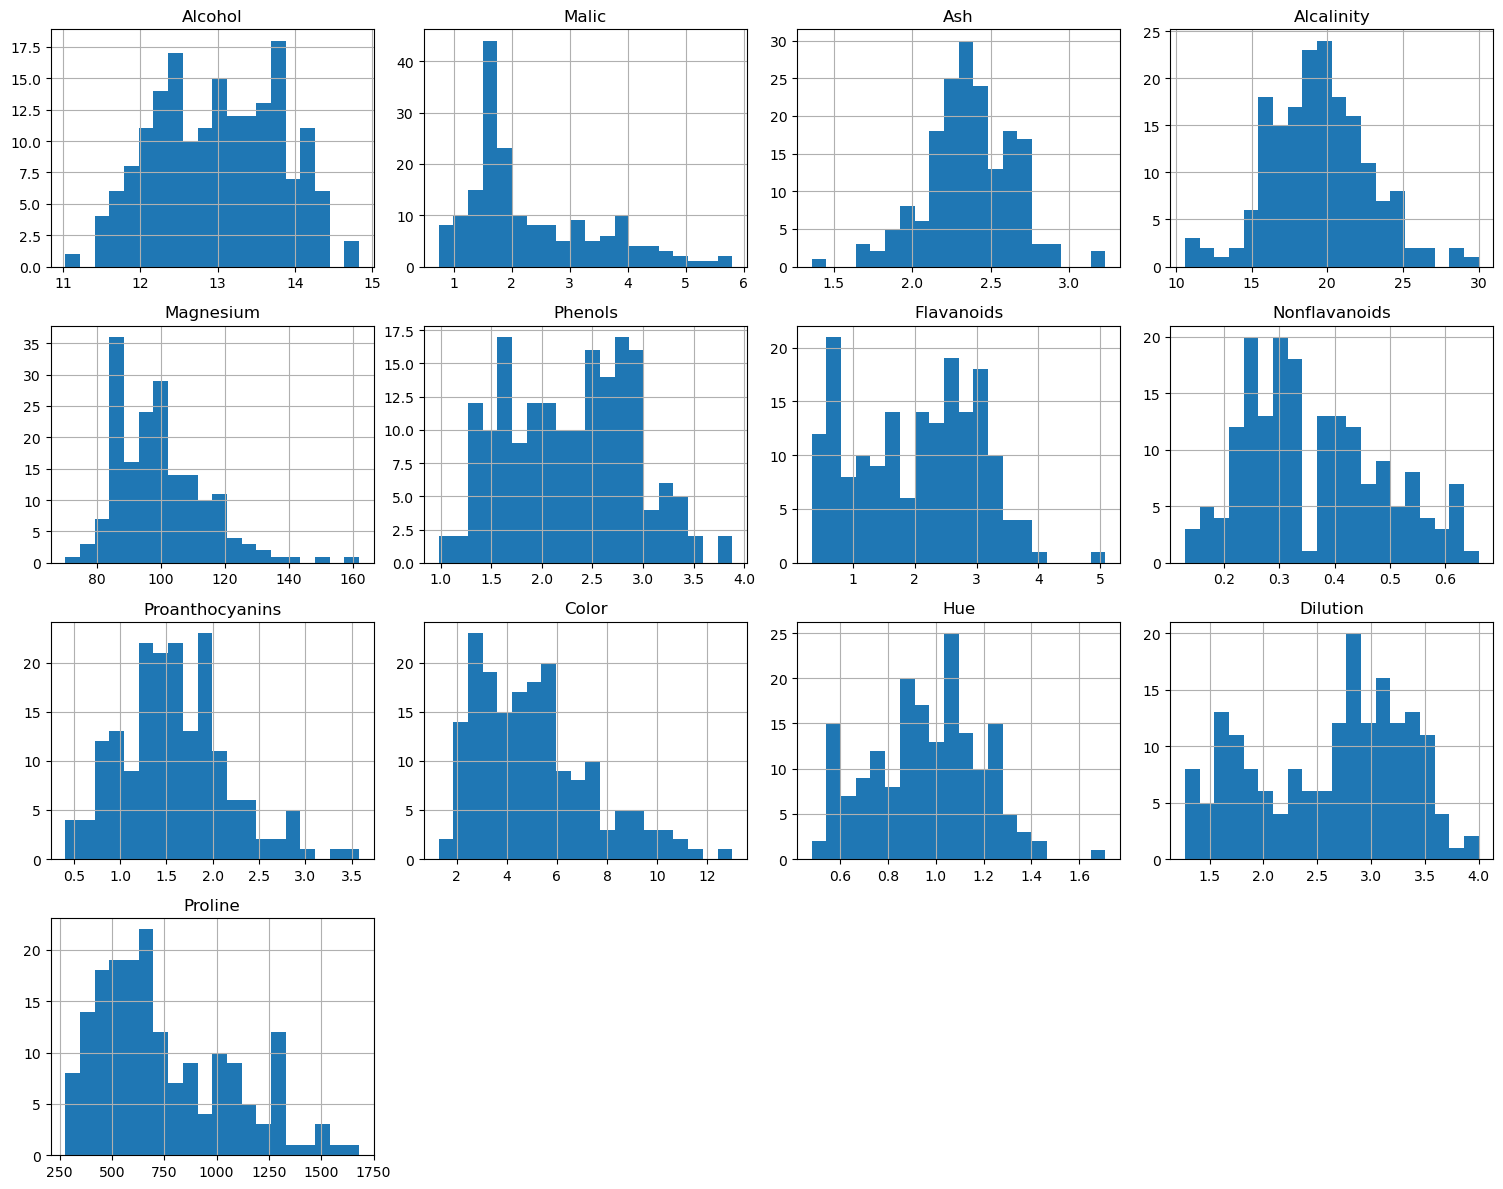

In [25]:
df.iloc[:, 1:].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

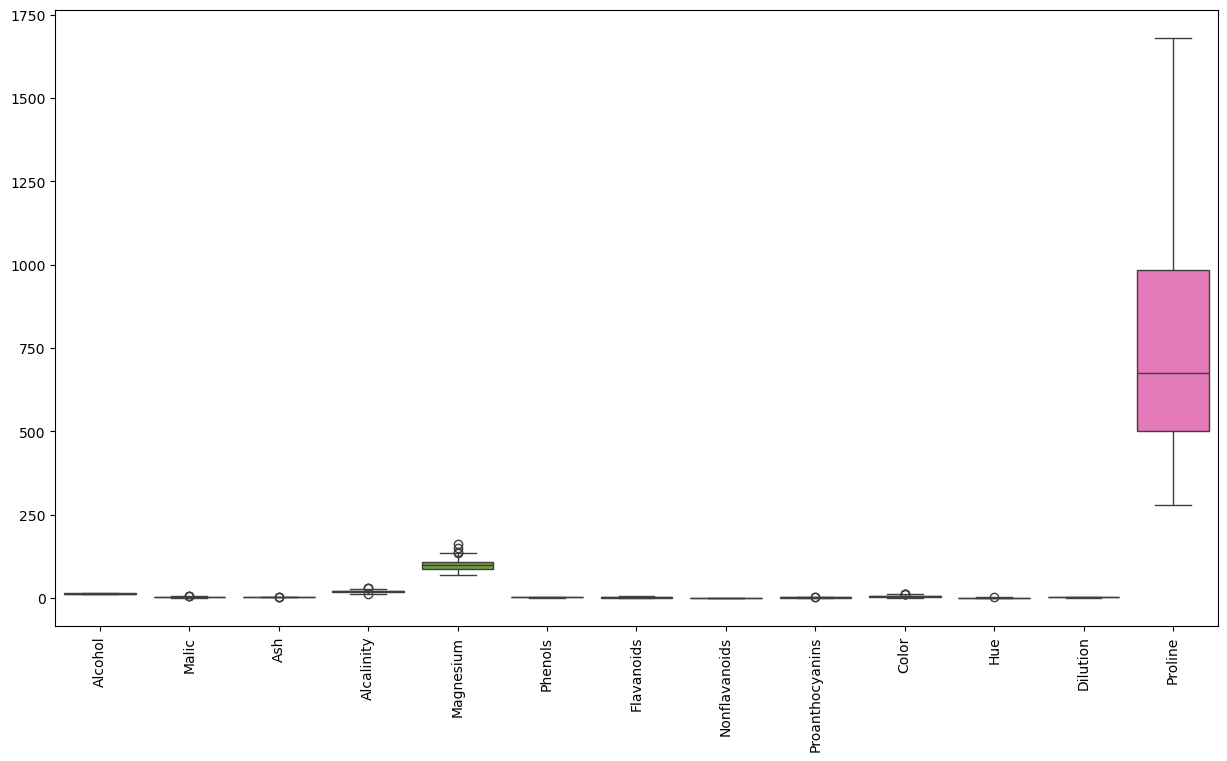

In [26]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.iloc[:, 1:])
plt.xticks(rotation=90)
plt.show()

## Task 2: Dimensionality Reduction with PCA:

1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

3.	Transform the original dataset into the principal components.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.iloc[:, 1:]  # features only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




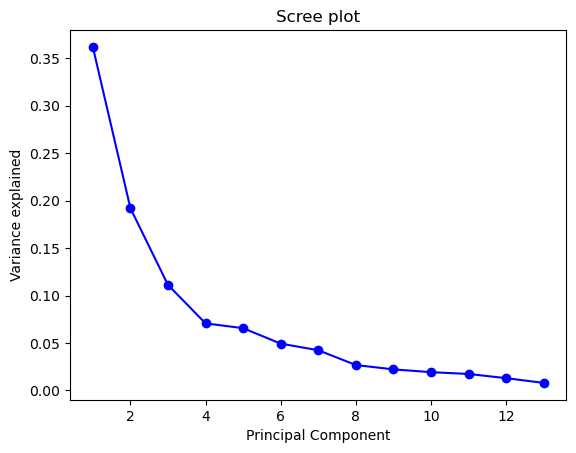

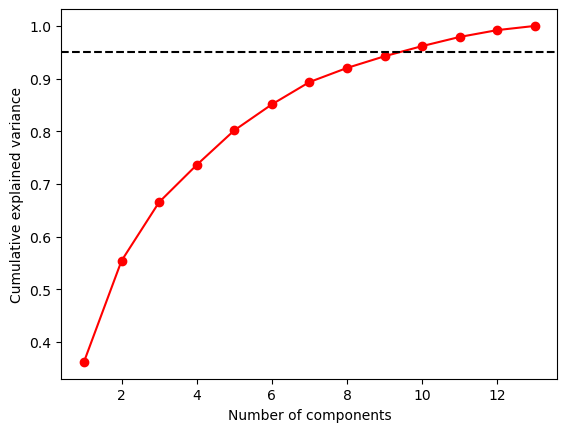

In [21]:
pca = PCA()
pca.fit(X_scaled)

# Scree plot
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Variance explained')
plt.title('Scree plot')
plt.show()

# Cumulative variance
cumulative = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative)+1), cumulative, 'ro-')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='k', linestyle='--')
plt.show()

## Task 3: Clustering with Original Data:

1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

2.	Visualize the clustering results using appropriate plots.

3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.


In [27]:
pca_3 = PCA(n_components=3)
X_pca = pca_3.fit_transform(X_scaled)

C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

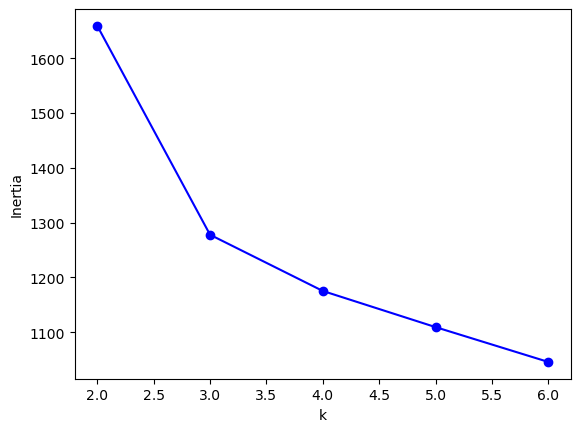

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Elbow method to find optimal k
inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 7), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

In [29]:
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
orig_labels = kmeans_orig.fit_predict(X_scaled)

C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


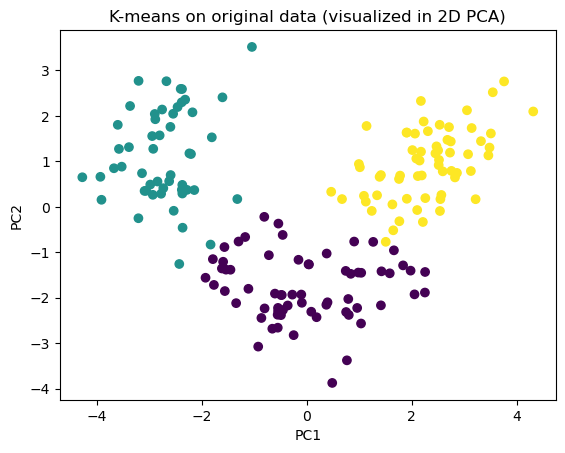

In [30]:
from sklearn.decomposition import PCA
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=orig_labels, cmap='viridis')
plt.title('K-means on original data (visualized in 2D PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [31]:
sil_orig = silhouette_score(X_scaled, orig_labels)
db_orig = davies_bouldin_score(X_scaled, orig_labels)
print(f"Silhouette (original): {sil_orig:.3f}")
print(f"Davies-Bouldin (original): {db_orig:.3f}")

Silhouette (original): 0.285
Davies-Bouldin (original): 1.389


## Task 4: Clustering with PCA Data:

1.	Apply the same clustering algorithm to the PCA-transformed dataset.

2.	Visualize the clustering results obtained from PCA-transformed data.

3.	Compare the clustering results from PCA-transformed data with those from the original dataset.


In [32]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_labels = kmeans_pca.fit_predict(X_pca)

C:\Users\yash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


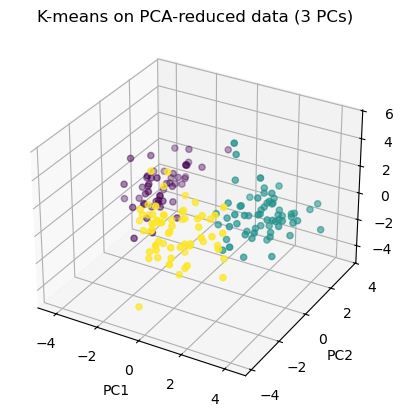

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=pca_labels, cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('K-means on PCA-reduced data (3 PCs)')
plt.show()

In [36]:
sil_pca = silhouette_score(X_pca, pca_labels)
db_pca = davies_bouldin_score(X_pca, pca_labels)

print(f"Silhouette (PCA): {sil_pca:.3f}")
print(f"Davies-Bouldin (PCA): {db_pca:.3f}")

# Compare labels with original clustering
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(orig_labels, pca_labels)
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette (PCA): 0.453
Davies-Bouldin (PCA): 0.840
Adjusted Rand Index: 0.982


## Task 5: Comparison and Analysis:

1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

2.	Discuss any similarities or differences observed in the clustering results.

3.	Reflect on the impact of dimensionality reduction on clustering performance.

4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.


In [ ]:
1. Similarities & differences
Both methods separate wines into 3 clusters, largely matching true types.

PCA clusters are slightly more compact (higher silhouette score).

2. Why PCA improves clustering slightly
PCA removes noise and redundant correlations.

Distances in high-dimensional space can be misleading (curse of dimensionality).

PCA focuses variance into first few components.

3. Impact of dimensionality reduction
Positive: Faster computation, easier visualization, often better cluster separation.

Negative: Loss of interpretability (clusters explained by PC combinations, not original features).

4. Trade-offs
Aspect	                                                   Original Data	                     PCA-transformed
Interpretability	                                       High (features known)	             Low (PCs are abstract)
Computation	                                               Slower (13D)	                         Faster (3D)
Noise handling	                                           Sensitive	                         Robust
Visualization	                                           Hard (needs PCA for plot)	         Easy (direct plot)
Clustering quality	                                       Good                                	 Slightly better

## Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.

2.	Discuss the practical implications of using PCA and clustering in data analysis.

3.	Provide recommendations for when to use each technique based on the analysis conducted.


## Key findings
The wine dataset has natural clustering related to wine types.

PCA with 3 components captures ~66% variance but improves clustering quality.

K-means on PCA yields slightly higher silhouette score and lower Davies-Bouldin index.

Clusters are visually separable in 3D PCA space.

Practical implications
## Use PCA when:

You have many correlated features.

You need to visualize clusters.

Speed is important.

Noise reduction is desired.

## Use original data when:

Interpretability is critical (e.g., explaining why a cluster exists).

Features are already low-dimensional.

You need feature importance.

## Recommendations
Always standardize before PCA.

Use elbow method and silhouette score to choose number of clusters.

Validate PCA clustering by comparing with original data clustering (ARI).

For final deployment, if interpretability matters, use original data or explain PCs via top contributing features.